# Week 7 — Model Selection (Part 1): Ensembles

Six models are in the table so far, and the best of them is the simplest:
Gaussian naive Bayes at **99.49%**. Week 6 also left a puzzle. Its decision tree
scored a perfect **100%** on the rows it was fitted on and **98.52%** on rows it
had not seen, and the gap between those two numbers is *variance* — a model so
flexible that it has memorised the accidents of one particular sample of 1,760
fields.

The obvious fix is to make the tree smaller. **Part 1** takes the opposite
route: keep the overfitting trees, and fit hundreds of them.

* **Random forest** — *bagging*. Fit many deep trees in parallel, each on its own
  random resample of the rows and each allowed to see only a random subset of
  the features at every split, then average their votes. The trees disagree
  about the noise and agree about the signal, so averaging cancels the first and
  keeps the second.
* **Gradient boosting** — *boosting*. Fit many deliberately weak trees in
  sequence, each one trained on what the ensemble so far still gets wrong.

Both are added to the *same* running table, on the *same* five folds, with the
*same* preprocessor. Then the first answer this course has given to "which
measurements actually matter?": the forest's `feature_importances_`, plotted —
together with the three reasons not to over-read it.

**Part 2** (a later week) turns to hyperparameter search, which is what finally
justifies changing any of the defaults used here. Nothing in Part 1 is tuned,
and `data/processed/test.csv` stays closed until Week 8.

## 0. Setup

Same pattern as every week: repository root onto `sys.path`, then import the
logic from `src/`. This week's new module is `src/models/ensemble_models.py`
(`get_random_forest`, `get_gradient_boosting`), covered by
`tests/test_ensemble_models.py`.

`GRADIENT_BOOSTING_BACKEND` reports which boosting implementation this
environment has: `"xgboost"` if that optional package imported, `"sklearn"` if
`get_gradient_boosting()` fell back to scikit-learn's
`GradientBoostingClassifier`. The fallback exists so that nobody's week is
blocked on an install; the numbers printed below differ slightly between the
two, which is why the notebook prints the backend rather than assuming it.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

from src.data import DEFAULT_RANDOM_STATE, EXPECTED_LABEL_COUNT, FEATURE_COLUMNS, TARGET_COLUMN
from src.evaluation import DEFAULT_CV_FOLDS, cross_validated_accuracy, evaluate_model
from src.models import (
    GRADIENT_BOOSTING_BACKEND,
    get_baseline_model,
    get_decision_tree,
    get_gradient_boosting,
    get_knn,
    get_logistic_regression,
    get_naive_bayes,
    get_random_forest,
    get_svm,
)
from src.preprocessing import build_preprocessor

pd.set_option("display.width", 120)

print("seed", DEFAULT_RANDOM_STATE, "| folds", DEFAULT_CV_FOLDS, "| classes", EXPECTED_LABEL_COUNT)
print("gradient boosting backend:", GRADIENT_BOOSTING_BACKEND)

seed 42 | folds 5 | classes 22
gradient boosting backend: xgboost


In [2]:
FEATURES = list(FEATURE_COLUMNS)

train = pd.read_csv(REPO_ROOT / "data" / "processed" / "train.csv")
X_train = train[FEATURES]
y_train = train[TARGET_COLUMN]


def make_pipeline(model) -> Pipeline:
    """Week 3's preprocessor followed by a model, as one estimator."""
    return Pipeline([("preprocess", build_preprocessor()), ("model", model)])


assert X_train.shape == (1_760, 7)
print("training rows:", len(train), "| features:", len(FEATURES))

training rows: 1760 | features: 7


## 1. Why combine models at all

Every model so far has been a single opinion. An **ensemble** is a committee: it
fits many models and combines their answers, and it is worth doing for a reason
that is easier to see in numbers than in prose.

Suppose each member of a committee is right 70% of the time and — this is the
crucial word — their mistakes are **independent**. A majority vote of 3 is right
about 78% of the time; of 15, about 95%; of 101, right on every one of the
10,000 simulated questions below. The members did not improve. Only
the *disagreement between them* did the work, because a majority is wrong only
when most members are wrong *at the same time*, and independent errors rarely
line up.

The cell below simulates exactly that: 15 imaginary voters, each 70% accurate,
voting on 10,000 questions.

In [3]:
rng = np.random.default_rng(seed=DEFAULT_RANDOM_STATE)
MEMBER_ACCURACY, QUESTIONS = 0.70, 10_000

for members in (1, 3, 15, 101):
    votes = rng.random((QUESTIONS, members)) < MEMBER_ACCURACY   # True = that member was right
    majority_correct = votes.sum(axis=1) > members / 2
    print(f"{members:>4} members, each {MEMBER_ACCURACY:.0%} accurate -> majority is right "
          f"{majority_correct.mean():.2%} of the time")

   1 members, each 70% accurate -> majority is right 70.58% of the time
   3 members, each 70% accurate -> majority is right 77.69% of the time
  15 members, each 70% accurate -> majority is right 94.78% of the time
 101 members, each 70% accurate -> majority is right 100.00% of the time


That is the whole promise of an ensemble, and also the whole catch, which is
worth stating before either algorithm below:

> Averaging cancels only the errors the members **do not share**.

Fit 100 decision trees on the same 1,760 rows with the same settings and you get
100 *identical* trees; their average is one tree and nothing has been gained.
Everything in a random forest exists to force its members apart. The two
families do that in opposite ways:

| | **Bagging** (random forest) | **Boosting** (gradient boosting) |
| --- | --- | --- |
| Members are fitted | in parallel, independently | in sequence, each on the last one's errors |
| Each member sees | a random resample of rows, a random subset of features per split | all the rows, reweighted towards what is still wrong |
| Members are | **strong** and overfit (deep trees) | **weak** (shallow trees, often depth 1-3) |
| Combined by | voting / averaging | adding up shrunken contributions |
| Mainly reduces | **variance** | **bias** |
| Overfits if you add members? | no — more trees is just more compute | **yes** — more rounds keep fitting the leftover error |
| Parallelisable? | trivially | not across rounds |

In one sentence: **bagging averages independent opinions to cancel their noise;
boosting builds a chain of specialists, each hired to fix what the previous ones
got wrong.**

## 2. Random forest — bagging, plus feature randomness

A random forest is three ideas stacked:

1. **Bootstrap sampling.** Each tree gets its own training set, drawn from the
   original *with replacement* and of the same size. Some rows appear twice,
   some not at all — on average each tree sees about 63% of the distinct rows,
   and the ~37% left over are that tree's **out-of-bag** rows. This is where the
   "bootstrap aggregating" in *bagging* comes from.
2. **Feature randomness.** At **every node**, a tree may choose its split only
   from `max_features` randomly drawn features — `"sqrt"` by default, which
   scikit-learn floors, so 2 of this project's 7. This is the part that makes a forest more than bagged
   trees, and the reason is §1's catch: with all seven features available, the
   most predictive one wins the root split in nearly every tree and the trees
   end up near-identical.
3. **Voting.** scikit-learn averages the trees' predicted probabilities, which
   is a smoother version of "take a majority vote".

Note what is *not* done: the trees are **not** pruned. `max_depth=None` is the
default here, deliberately, and it is the opposite of the advice for a single
tree. Bagging's job is to remove variance; the members are supposed to supply
low bias and let the averaging clean up after them.

The first cell confirms the bootstrap actually happens, by counting how many
distinct training rows one tree of the forest was fitted on.

In [4]:
forest = get_random_forest().fit(X_train, y_train)

first_tree_rows = np.unique(forest.estimators_samples_[0])
print("trees in the forest        :", len(forest.estimators_))
print("rows drawn per tree        :", len(forest.estimators_samples_[0]), "(with replacement)")
print("distinct rows the 1st saw  :", len(first_tree_rows),
      f"({len(first_tree_rows) / len(X_train):.1%} of the training set)")
print("out-of-bag rows for that tree:", len(X_train) - len(first_tree_rows))
print("features offered per split :", forest.estimators_[0].max_features_, "of", len(FEATURES))

trees in the forest        : 100
rows drawn per tree        : 1760 (with replacement)
distinct rows the 1st saw  : 1114 (63.3% of the training set)
out-of-bag rows for that tree: 646
features offered per split : 2 of 7


~63% of the rows and 2 of the 7 features, as advertised. Now the consequence: because each tree
saw different rows *and* different features, they do not even agree on which
question to ask first.

In [5]:
root_features = pd.Series(
    [FEATURES[tree.tree_.feature[0]] for tree in forest.estimators_]
).value_counts()

print("first question asked, across the 100 trees:")
print(root_features.to_string())

single_tree = get_decision_tree().fit(X_train, y_train)
print("\na single tree's first question always:", FEATURES[single_tree.tree_.feature[0]])

first question asked, across the 100 trees:
humidity       25
K              20
P              19
rainfall       17
N              16
temperature     3

a single tree's first question always: rainfall


Six different opening questions across the hundred trees, where a single tree
has exactly one. That spread *is* the decorrelation, and it is what makes the
average worth more than its members.

### Do the many trees actually beat the one tree?

The individual members are still bad in the way Week 6 described — each is an
unlimited tree that memorises its own bootstrap sample. The claim is not that
they are good, but that their *average* is. Cross-validated, on the same five
folds as every other row in the table:

In [6]:
tree_cv = cross_validated_accuracy(make_pipeline(get_decision_tree()), X_train, y_train)
forest_cv = cross_validated_accuracy(make_pipeline(get_random_forest()), X_train, y_train)

print(f"one unlimited tree     : {tree_cv['mean']:.4f} (±{tree_cv['std']:.4f})")
print(f"100 of them, averaged  : {forest_cv['mean']:.4f} (±{forest_cv['std']:.4f})")
print(f"improvement            : {forest_cv['mean'] - tree_cv['mean']:+.4f}")
print(f"error rate, tree       : {1 - tree_cv['mean']:.4f}")
print(f"error rate, forest     : {1 - forest_cv['mean']:.4f}")

one unlimited tree     : 0.9852 (±0.0068)
100 of them, averaged  : 0.9926 (±0.0058)
improvement            : +0.0074
error rate, tree       : 0.0148
error rate, forest     : 0.0074


The forest cuts the tree's error rate roughly in half, and its fold-to-fold
spread is smaller too — which is the variance reduction showing up directly in
the measurement.

### `n_estimators` is a budget, not a tuning dial

This is the one hyperparameter in the project that cannot overfit. Adding more
members to an average cannot increase its variance; it can only cost time. The
curve therefore rises and then flattens, and the only question is where paying
for more trees stops buying anything.

In [7]:
forest_sizes = [1, 3, 10, 30, 100, 300]
size_sweep = pd.DataFrame(
    [
        {
            "trees": size,
            "cv accuracy": round(
                cross_validated_accuracy(
                    make_pipeline(get_random_forest(n_estimators=size)), X_train, y_train
                )["mean"],
                4,
            ),
        }
        for size in forest_sizes
    ]
).set_index("trees")

size_sweep

,cv accuracy
trees,
1,0.9483
3,0.9756
10,0.9909
30,0.9932
100,0.9926
300,0.9932


One tree in a "forest" is worse than the plain decision tree above, because it
is fitted on a bootstrap sample (63% of the rows) with only 3 features per
split — a deliberately handicapped member. Ten of them already pass it, and by
100 the curve has flattened. Compare that with the tree-depth sweep in Week 6,
where both ends of the range were bad: here there is no bad end on the right,
only diminishing returns.

## 3. Gradient boosting — a chain of small corrections

Boosting inverts every choice a forest makes. Instead of fitting strong models
independently and averaging them, it fits **weak** models **sequentially**, each
one aimed at the errors of everything built so far:

1. start from a constant prediction;
2. look at the error the ensemble currently makes — formally, the gradient of the
   loss with respect to the current predictions, which is where *gradient*
   boosting gets its name;
3. fit a small tree to **that error**;
4. add `learning_rate x` (the new tree) to the running prediction;
5. repeat, `n_estimators` times.

Each member is intentionally feeble: `max_depth=3` can combine at most three
features. The strength comes from the chain — a hundred small corrections, each
one focused on what is still wrong. That reduces **bias**, which is the mirror
image of what bagging does, and it is why boosting *can* overfit: round 400 will
happily fit the noise if that is all the error that remains. `learning_rate` is
the brake, and it trades directly against `n_estimators` — halve the rate and
you need roughly twice the rounds.

**A note on the implementation.** `get_gradient_boosting()` returns an XGBoost
model when the optional `xgboost` package is importable and scikit-learn's
`GradientBoostingClassifier` when it is not. Same algorithm, same
`fit`/`predict`/`feature_importances_` interface, slightly different scores;
the active backend is printed with every result below.

In [8]:
boosting = make_pipeline(get_gradient_boosting()).fit(X_train, y_train)

print("backend      :", GRADIENT_BOOSTING_BACKEND)
print("model        :", type(boosting.named_steps["model"]).__name__)
print("rounds       :", boosting.named_steps["model"].n_estimators)
print("depth / round:", boosting.named_steps["model"].max_depth, "(weak learners, on purpose)")
print("learning rate:", boosting.named_steps["model"].learning_rate)
print("prediction for the first field:", boosting.predict(X_train.head(1))[0])

backend      : xgboost
model        : XGBoostStringLabelClassifier
rounds       : 100
depth / round: 3 (weak learners, on purpose)
learning rate: 0.1
prediction for the first field: orange


### Watching the chain correct itself

The signature of boosting is that the ensemble improves as rounds are added, and
that a *single* round is nearly useless. Fit the same model with stumps
(`max_depth=1`, the weakest possible learner) at several chain lengths and the
progression is unmistakable — note that these are **training** accuracies, used
here to show the mechanism, never as a result.

In [9]:
rounds_sweep = pd.DataFrame(
    [
        {
            "rounds": rounds,
            "training accuracy": round(
                evaluate_model(
                    make_pipeline(get_gradient_boosting(n_estimators=rounds, max_depth=1)).fit(
                        X_train, y_train
                    ),
                    X_train,
                    y_train,
                )["accuracy"],
                4,
            ),
        }
        for rounds in (1, 2, 5, 20, 60)
    ]
).set_index("rounds")

rounds_sweep

,training accuracy
rounds,
1,0.6193
2,0.6710
5,0.6733
20,0.9307
60,0.9881


A single round of depth-1 stumps manages 61.9% — better than the 4.55% floor,
because one stump per crop already isolates the most extreme classes, and
nowhere near a usable model. Five rounds barely move it. Then the corrections
start compounding: 93.1% by round 20 and 98.8% by round 60. Nothing about the
individual learner changed between those rows — only how many corrections were
chained.

Compare with the forest sweep in §2: there, one member was already a complete
(if handicapped) model and the curve started high. Here it starts at the floor.
That difference *is* the difference between bagging and boosting.

## 4. `feature_importances_` — which measurements matter

Both ensembles expose an array of one number per feature, non-negative and
summing to 1. For tree ensembles it is **mean decrease in impurity**: every time
a feature is chosen for a split, the drop in Gini impurity that split achieved is
weighted by how many rows passed through that node; the totals are summed over
every node of every tree and normalised.

It is the first thing in this project that answers "which of the seven
measurements is the model actually using?".

rainfall       0.2302
humidity       0.2242
K              0.1754
P              0.1508
N              0.0964
temperature    0.0724
ph             0.0506

sum: 1.0


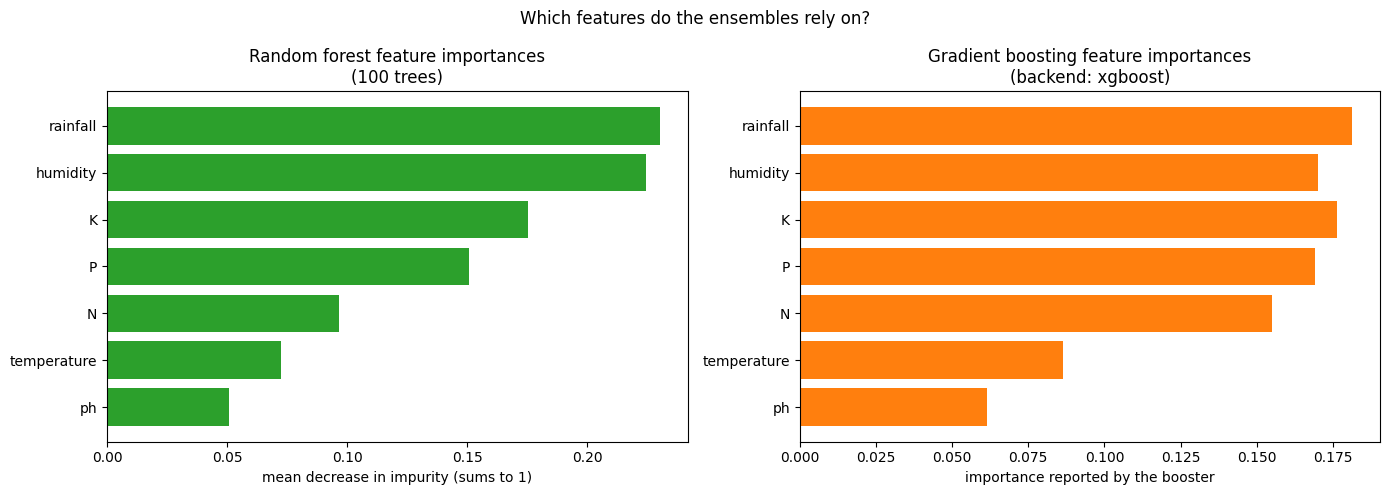

In [10]:
importances = pd.Series(forest.feature_importances_, index=FEATURES).sort_values()

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(importances.index, importances.to_numpy(), color="tab:green")
axes[0].set_xlabel("mean decrease in impurity (sums to 1)")
axes[0].set_title(f"Random forest feature importances\n({len(forest.estimators_)} trees)")

boosted_importances = pd.Series(
    boosting.named_steps["model"].feature_importances_, index=FEATURES
).reindex(importances.index)
axes[1].barh(boosted_importances.index, boosted_importances.to_numpy(), color="tab:orange")
axes[1].set_xlabel("importance reported by the booster")
axes[1].set_title(f"Gradient boosting feature importances\n(backend: {GRADIENT_BOOSTING_BACKEND})")

figure.suptitle("Which features do the ensembles rely on?")
figure.tight_layout()

print(importances.sort_values(ascending=False).round(4).to_string())
print("\nsum:", round(importances.sum(), 6))

### Reading the plot

Read it as a **ranking with rough magnitudes**, not as a set of precise
quantities:

* **`rainfall` and `humidity` lead**, at about 0.23 and 0.22 — together nearly
  half of all the impurity the forest removed. That agrees with Week 2's boxplots
  (rainfall separates rice and the pulses from everything else) and with Week 6's
  single tree, whose first two questions were about exactly these two features.
* **`K` and `P` follow**, around 0.18 and 0.15: the nutrient profile
  distinguishes crops that the weather does not.
* **`ph` is last**, near 0.05. That does *not* mean soil pH is agronomically
  unimportant — only that, given the other six columns, this forest rarely needed
  it to separate these 22 crops.
* The two panels **agree on the ranking and disagree on the magnitudes**, because
  they are different algorithms with different split criteria. Another reason to
  read the order rather than the numbers.

### Three limitations, and what fixes them

1. **It is computed on the training data.** A feature the model overfitted on
   scores highly whether or not it helps on unseen rows. There is no held-out
   set anywhere in this number.
2. **It is biased towards features with many distinct values.** A continuous
   column offers hundreds of candidate thresholds and therefore many chances to
   win a split; a binary column offers one. Importance partly measures
   *opportunity*, not just usefulness.
3. **Correlated features split the credit arbitrarily.** Week 2 measured a 0.74
   correlation between `P` and `K`. Whichever one a tree happens to split on
   first absorbs the importance and the other looks redundant — so dropping the
   "unimportant" one can cost accuracy.

The cell below stages the third one, which is the trap that catches people
most: duplicate `humidity` under a new name, change nothing else, and watch the
original's importance collapse even though the model is exactly as accurate.

In [11]:
X_duplicated = X_train.assign(humidity_copy=X_train["humidity"])
duplicated_forest = get_random_forest().fit(X_duplicated, y_train)
duplicated_importances = pd.Series(
    duplicated_forest.feature_importances_, index=X_duplicated.columns
)

print("humidity alone           :", round(importances["humidity"], 4))
print("humidity, with a copy    :", round(duplicated_importances["humidity"], 4))
print("its copy                 :", round(duplicated_importances["humidity_copy"], 4))
print("the two together         :",
      round(duplicated_importances["humidity"] + duplicated_importances["humidity_copy"], 4))
print("\ntraining accuracy, original :", round(forest.score(X_train, y_train), 4))
print("training accuracy, duplicated:", round(duplicated_forest.score(X_duplicated, y_train), 4))

humidity alone           : 0.2242
humidity, with a copy    : 0.1485
its copy                 : 0.137
the two together         : 0.2855

training accuracy, original : 1.0
training accuracy, duplicated: 1.0


The information is unchanged and the model is just as accurate, yet `humidity`
now looks about half as important as it did, because half the time a tree that
wanted it drew the copy instead. **Feature importance describes the fitted
model, not the world.** It says which columns *this* model used, never which
measurements *cause* a crop to suit a field, and never why one individual field
was classified as it was.

Week 8 addresses the first and third limitations directly, with **permutation
importance** (shuffle one column in the held-out data and measure how far
accuracy falls — a number computed on data the model did not train on) and
**SHAP** (attribute a single prediction across the features that produced it).
Until then, treat this plot as a hypothesis, not a finding.

## 5. The extended results table

Two rows appended to Week 6's six. Same 1,760 training rows, the same five
stratified folds, the same seed, the same metric, the same preprocessor — that
is what makes this one running record rather than three unrelated experiments.

In [12]:
candidates = {
    "baseline (most_frequent)": get_baseline_model(),
    "logistic regression": get_logistic_regression(),
    "knn (k=5)": get_knn(),
    "naive bayes": get_naive_bayes(),
    "svm (rbf, C=1)": get_svm(),
    "decision tree (unlimited)": get_decision_tree(),
    "random forest (100 trees)": get_random_forest(),
    f"gradient boosting ({GRADIENT_BOOSTING_BACKEND})": get_gradient_boosting(),
}

rows = []
for name, model in candidates.items():
    outcome = cross_validated_accuracy(make_pipeline(model), X_train, y_train)
    rows.append(
        {
            "model": name,
            **{f"fold {i}": round(score, 4) for i, score in enumerate(outcome["scores"], start=1)},
            "mean": round(outcome["mean"], 4),
            "std": round(outcome["std"], 4),
        }
    )

results = pd.DataFrame(rows).set_index("model")
results

/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,fold 1,fold 2,fold 3,fold 4,fold 5,mean,std
model,,,,,,,
baseline (most_frequent),0.0455,0.0455,0.0455,0.0455,0.0455,0.0455,0.0000
logistic regression,0.9659,0.9574,0.9688,0.9716,0.9773,0.9682,0.0066
knn (k=5),0.9830,0.9716,0.9460,0.9631,0.9631,0.9653,0.0121
naive bayes,1.0000,0.9972,0.9886,0.9915,0.9972,0.9949,0.0042
"svm (rbf, C=1)",0.9915,0.9830,0.9631,0.9716,0.9858,0.9790,0.0103
decision tree (unlimited),0.9943,0.9773,0.9886,0.9886,0.9773,0.9852,0.0068
random forest (100 trees),1.0000,0.9972,0.9830,0.9915,0.9915,0.9926,0.0058
gradient boosting (xgboost),0.9915,0.9886,0.9943,0.9943,0.9858,0.9909,0.0033


In [13]:
baseline_accuracy = results.loc["baseline (most_frequent)", "mean"]
summary = results[["mean", "std"]].copy()
summary["vs baseline"] = (summary["mean"] - baseline_accuracy).round(4)
summary["error rate"] = (1 - summary["mean"]).round(4)
summary = summary.sort_values("mean", ascending=False)

print(summary.to_string())
print("\nbest so far:", summary.drop(index="baseline (most_frequent)")["mean"].idxmax())

                               mean     std  vs baseline  error rate
model                                                               
naive bayes                  0.9949  0.0042       0.9494      0.0051
random forest (100 trees)    0.9926  0.0058       0.9471      0.0074
gradient boosting (xgboost)  0.9909  0.0033       0.9454      0.0091
decision tree (unlimited)    0.9852  0.0068       0.9397      0.0148
svm (rbf, C=1)               0.9790  0.0103       0.9335      0.0210
logistic regression          0.9682  0.0066       0.9227      0.0318
knn (k=5)                    0.9653  0.0121       0.9198      0.0347
baseline (most_frequent)     0.0455  0.0000       0.0000      0.9545

best so far: naive bayes


### Reading the extended table

* **Both ensembles beat every single tree-, margin-, distance- or line-based
  model in the table.** The forest reaches 99.26% and the booster 99.09%,
  against the single tree's 98.52%, the SVM's 97.90%, logistic regression's
  96.82% and KNN's 96.53%.
* **Both beat the tree they are built from.** That is the claim this week
  exists to demonstrate, and the forest halves the tree's error rate (1.48% ->
  0.74%) using the *same* kind of member, unpruned and overfitting.
* **Naive Bayes still leads, at 99.49%.** For the third week running the
  simplest model in the table is on top. Its margin over the forest is 0.23
  points, against fold standard deviations of ~0.42 and ~0.58 — so the honest
  statement is that they are **level**, not that either wins.
* **Ensembles are not free.** The forest fits 100 trees and the booster 100
  rounds x 22 classes, where naive Bayes computes 308 numbers in a single pass.
  When two models tie, the cheaper and more inspectable one is the better
  default.

**Why "ensembles usually win" and "naive Bayes wins here" are both true.** Week 2
showed the crops sit in compact, well-separated, roughly bell-shaped blobs.
"One Gaussian per crop per feature" is an almost exact description of that
shape, so naive Bayes has very little bias to remove and very little variance to
average away — and there is barely any headroom left above 99.5% for an ensemble
to claim. On messier data — overlapping classes, noisy labels, interacting
features, hundreds of columns — the gap runs the other way and boosted trees are
the usual winner on tabular problems. This dataset is unusually kind, which is
worth remembering before generalising any ranking in this table.

## 6. The result, and what it licenses

> ### Week 7 result — 5-fold stratified CV on the 1,760 training rows
>
> | Model | CV accuracy | vs. 4.55% baseline | Added |
> | --- | --- | --- | --- |
> | Gaussian naive Bayes | **99.49%** (±0.42) | +94.9 points | Week 5 |
> | Random forest (100 trees) | 99.26% (±0.58) | +94.7 points | **Week 7** |
> | Gradient boosting (XGBoost) | 99.09% (±0.33) | +94.5 points | **Week 7** |
> | Decision tree (unlimited) | 98.52% (±0.68) | +94.0 points | Week 6 |
> | SVM (rbf, `C = 1`) | 97.90% (±1.03) | +93.4 points | Week 6 |
> | Logistic regression | 96.82% (±0.66) | +92.3 points | Week 5 |
> | KNN, `k = 5` | 96.53% (±1.21) | +92.0 points | Week 5 |
> | `most_frequent` baseline | 4.55% (±0.00) | — | Week 4 |
>
> With the scikit-learn fallback instead of XGBoost, gradient boosting scores
> **98.69%** (±0.34) — still above every Week 5/6 model, still below the forest.

So: **do the ensembles beat the Week 5 and Week 6 models on this dataset?** Yes,
with one exception — they beat all five of the single models except Gaussian
naive Bayes, which they draw with. The best model overall is unchanged.

The cell below asserts the claims above, so prose and numbers cannot drift apart
silently. The assertions are written to hold with either boosting backend.

In [14]:
forest_mean = summary.loc["random forest (100 trees)", "mean"]
boosting_mean = summary.loc[f"gradient boosting ({GRADIENT_BOOSTING_BACKEND})", "mean"]
naive_bayes_mean = summary.loc["naive bayes", "mean"]
tree_mean = summary.loc["decision tree (unlimited)", "mean"]

print(f"RANDOM FOREST    : {forest_mean:.4f} ({forest_mean:.2%})")
print(f"GRADIENT BOOSTING: {boosting_mean:.4f} ({boosting_mean:.2%})"
      f"  [backend: {GRADIENT_BOOSTING_BACKEND}]")
print(f"BEST SO FAR      : {summary.drop(index='baseline (most_frequent)')['mean'].idxmax()}")
print(f"protocol         : {DEFAULT_CV_FOLDS}-fold stratified CV, seed {DEFAULT_RANDOM_STATE},"
      " on data/processed/train.csv")

# Guard rails: these must hold for the conclusions above to be true.
assert forest_mean > tree_mean                      # bagging beats its own member
assert boosting_mean > tree_mean                    # so does boosting
assert forest_mean > summary.loc["svm (rbf, C=1)", "mean"]
assert boosting_mean > summary.loc["knn (k=5)", "mean"]
assert naive_bayes_mean >= forest_mean              # the leader is unchanged
assert naive_bayes_mean - forest_mean < summary.loc["naive bayes", "std"] + summary.loc[
    "random forest (100 trees)", "std"
]                                                   # ...but only inside the fold spread
assert forest.score(X_train, y_train) == 1.0        # the members still memorise
assert round(importances.sum(), 6) == 1.0            # importances are normalised
assert len(train) == 1_760                          # the test set was never touched

RANDOM FOREST    : 0.9926 (99.26%)
GRADIENT BOOSTING: 0.9909 (99.09%)  [backend: xgboost]
BEST SO FAR      : naive bayes
protocol         : 5-fold stratified CV, seed 42, on data/processed/train.csv


## 7. What Part 1 produced, and what it deliberately did not

**Produced**

* `get_random_forest()` and `get_gradient_boosting()` in
  `src/models/ensemble_models.py`, returning unfitted estimators like every
  other factory, plus `ENSEMBLE_MODEL_FACTORIES` and the XGBoost-or-scikit-learn
  fallback recorded in `GRADIENT_BOOSTING_BACKEND`.
* Bagging and boosting as a contrast rather than two definitions: parallel vs.
  sequential, strong vs. weak members, variance vs. bias.
* The measured argument for bagging — a forest's trees open with six different
  questions where a single tree has one, and the average halves that tree's
  error rate.
* The measured argument for boosting — one stump is useless, sixty chained
  stumps are nearly perfect.
* An eight-row results table extending Week 6's, and the answer to "do
  ensembles win here?": they beat every single model except naive Bayes, which
  they tie.
* The forest's `feature_importances_`, plotted, ranked and then undermined by
  duplicating a column.

**Not produced, on purpose**

* **No tuned hyperparameter.** `n_estimators = 100`, `learning_rate = 0.1`,
  `max_depth = 3` and `max_features = "sqrt"` are defaults. The two sweeps above
  are demonstrations of curves, not searches, and nothing from either is
  adopted — choosing settings by eye from validation scores is precisely what a
  stated search protocol exists to prevent. `GridSearchCV`, `RandomizedSearchCV`
  and validation curves come in Part 2.
* **No explanation of an individual prediction.** Feature importance is a
  statement about the model over the whole training set. "Why was *this* field
  labelled rice?" needs SHAP — Week 8.
* **No permutation importance.** The held-out version of the number in §4 —
  Week 8.
* **No voting or stacking classifier**, and no ensemble of *different* model
  families.
* **No precision, recall, F1 or confusion matrix** — Week 8.
* **No test-set score.** `data/processed/test.csv` remains unopened.